# Inventory Optimization using a Periodic Review Order-Up-To Policy

## Project Overview

Demand forecasting alone is insufficient for supply chain decision-making. Forecasts must be converted into actionable inventory decisions.

This notebook simulates a retail inventory system using the demand forecasts generated in the previous notebook. A Periodic Review Order-Up-To policy is implemented to determine replenishment quantities while balancing service level and inventory cost.

---

## Objectives

- Simulate weekly inventory dynamics
- Compute safety stock
- Generate replenishment orders
- Measure stockouts and inventory levels
- Evaluate inventory performance using business KPIs

In [35]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import pandas as pd

from src.data_loader import load_and_merge
from src.preprocessing import preprocess
from src.feature_engineering import (
    build_features,
)

from src.forecasting import (
    temporal_split,
    train_model,
    predict,
)

from src.inventory import InventorySimulator
from src.metrics import metrics_to_dict
from src.utils import print_kpis

## Generate Demand Forecasts

The inventory simulator requires demand forecasts as input.

To keep this notebook self-contained, the forecasting pipeline is executed once before inventory optimization.

In [36]:
df = load_and_merge("../data")

df = preprocess(df)

df = build_features(df)

train_df, test_df = temporal_split(df)

model = train_model(train_df)

test_df["Predicted_Sales"] = predict(
    model,
    test_df,
)

test_df["Demand_For_Replenishment"] = (
    test_df["Predicted_Sales"]
    .clip(lower=0)
)

test_df["Actual_Sales"] = (
    test_df["Weekly_Sales"]
)

In [37]:
test_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Lag_1,Lag_4,Lag_8,Lag_12,Rolling_Mean_4,Rolling_Mean_8,Rolling_Mean_12,Predicted_Sales,Demand_For_Replenishment,Actual_Sales
88,1,1,2012-01-06,16567.69,False,49.01,3.157,6277.39,21813.16,143.10,...,23350.88,33305.92,18689.54,23077.55,37304.6450,29145.44000,29254.902500,16211.942383,16211.942383,16567.69
89,1,1,2012-01-13,16894.40,False,48.53,3.261,5183.29,8025.87,42.24,...,16567.69,45773.03,19050.66,23351.80,33120.0875,28880.20875,28712.414167,12784.014648,12784.014648,16894.40
90,1,1,2012-01-20,18365.10,False,54.11,3.268,4139.87,2807.19,33.88,...,16894.40,46788.75,20911.25,31579.90,25900.4300,28610.67625,28174.297500,15448.281250,15448.281250,18365.10
91,1,1,2012-01-27,18378.16,False,54.26,3.290,1164.46,1082.74,44.00,...,18365.10,23350.88,25293.49,39886.06,18794.5175,28292.40750,27073.064167,18454.292969,18454.292969,18378.16
92,1,1,2012-02-03,23510.49,False,56.55,3.360,34577.06,3579.21,160.53,...,18378.16,16567.69,33305.92,18689.54,17551.3375,27427.99125,25280.739167,18845.250000,18845.250000,23510.49


## Inventory Simulation

The simulator models a weekly periodic review inventory system.

Business assumptions:

- Review Period = 1 week
- Lead Time = 2 weeks
- Target Service Level = 95%
- Initial Inventory = 120% of expected demand

In [38]:
simulator = InventorySimulator()

In [39]:
simulation_df, metrics = simulator.simulate(
    test_df
)

sim_df = simulation_df

## Inventory Performance Metrics

The inventory simulator computes key operational metrics that quantify service quality, inventory utilization, and replenishment cost.

These KPIs help evaluate how well the inventory policy performs under forecasted demand.

In [40]:
kpis = metrics_to_dict(metrics)

kpis

{'Fill_Rate_%': np.float32(100.0),
 'Stockout_Rate_%': 0.05,
 'Total_Stockout_Volume': np.float32(6377.57),
 'Avg_Ending_Inventory': 7285.83,
 'Avg_Order_Quantity': 14569.38,
 'Holding_Cost_$': np.float64(231181303.65),
 'Ordering_Cost_$': 5774300.0,
 'Total_Cost_$': np.float64(236955603.65)}

In [41]:
print_kpis(kpis)


BUSINESS KPIs
Fill_Rate_%                    100.0
Stockout_Rate_%                0.05
Total_Stockout_Volume          6377.56982421875
Avg_Ending_Inventory           7285.83
Avg_Order_Quantity             14569.38
Holding_Cost_$                 231181303.65
Ordering_Cost_$                5774300.0
Total_Cost_$                   236955603.65



## Inventory Simulation Output

The simulation tracks inventory dynamics for every Store–Department pair over time.

Key variables include:

- Beginning Inventory
- Ending Inventory
- Target Inventory
- Order Quantity
- Safety Stock
- Stockout Events

In [42]:
simulation_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Demand_For_Replenishment,Actual_Sales,Beginning_Inventory,Target_Inventory,Order_Quantity,Ending_Inventory,Inventory_Level,Safety_Stock,Stockout,Stockout_Volume
0,1,1,2012-01-06,16567.69,False,49.01,3.157,6277.39,21813.16,143.10,...,16211.942383,16567.69,58362.996094,64226.683281,5863.687187,42151.054688,42151.054688,19782.444999,0,0.0
1,1,1,2012-01-13,16894.40,False,48.53,3.261,5183.29,8025.87,42.24,...,12784.014648,16894.40,42151.054688,66469.034843,18454.292969,29367.039062,29367.039062,19782.444999,0,0.0
2,1,1,2012-01-20,18365.10,False,54.11,3.268,4139.87,2807.19,33.88,...,15448.281250,18365.10,35230.726249,72530.269218,18845.250000,19782.444999,19782.444999,19782.444999,0,0.0
3,1,1,2012-01-27,18378.16,False,54.26,3.290,1164.46,1082.74,44.00,...,18454.292969,18378.16,38236.737968,88338.249687,31256.261719,19782.444999,19782.444999,19782.444999,0,0.0
4,1,1,2012-02-03,23510.49,False,56.55,3.360,34577.06,3579.21,160.53,...,18845.250000,23510.49,38627.694999,102401.952812,32517.996094,19782.444999,19782.444999,19782.444999,0,0.0


## Inventory Level over Time

This plot illustrates how inventory evolves during the simulation.

Inventory decreases as demand is fulfilled and increases whenever replenishment orders arrive.

Visualizing Store 3, Department 60


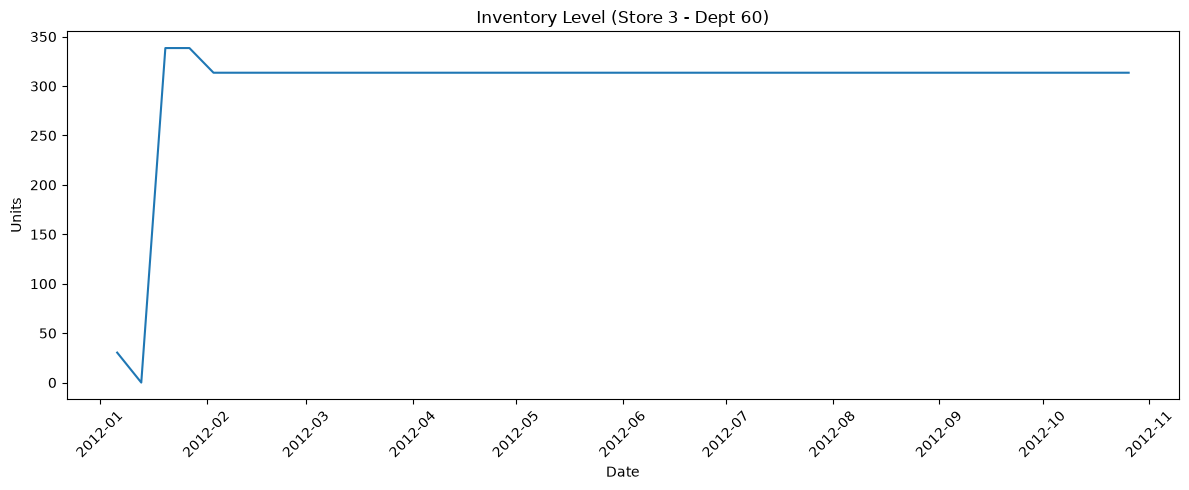

In [43]:

top_pair = (
    simulation_df
    .groupby(["Store", "Dept"])["Stockout"]
    .sum()
    .idxmax()
)

store, dept = top_pair

sample = (
    simulation_df
    .query("Store == @store and Dept == @dept")
    .copy()
)

print(f"Visualizing Store {store}, Department {dept}")

plt.figure(figsize=(12,5))

plt.plot(
    sample["Date"],
    sample["Inventory_Level"],
)

plt.title(
    f"Inventory Level (Store {store} - Dept {dept})"
)

plt.xlabel("Date")
plt.ylabel("Units")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Weekly Order Quantities

Replenishment orders are generated whenever the inventory position falls below the target Order-Up-To level.

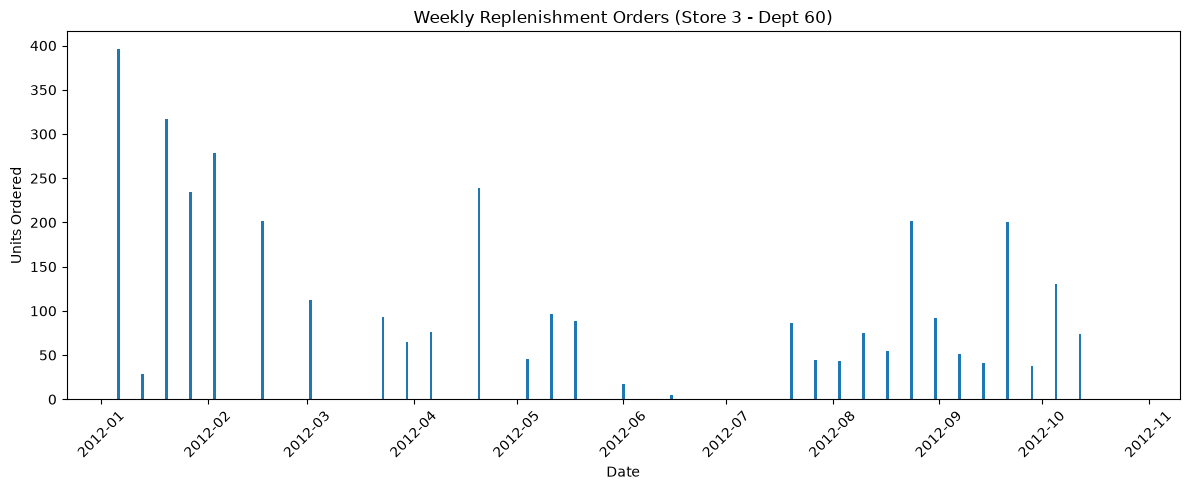

In [44]:
plt.figure(figsize=(12,5))

plt.bar(
    sample["Date"],
    sample["Order_Quantity"],
)

plt.title(
    f"Weekly Replenishment Orders (Store {store} - Dept {dept})"
)

plt.xlabel("Date")
plt.ylabel("Units Ordered")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

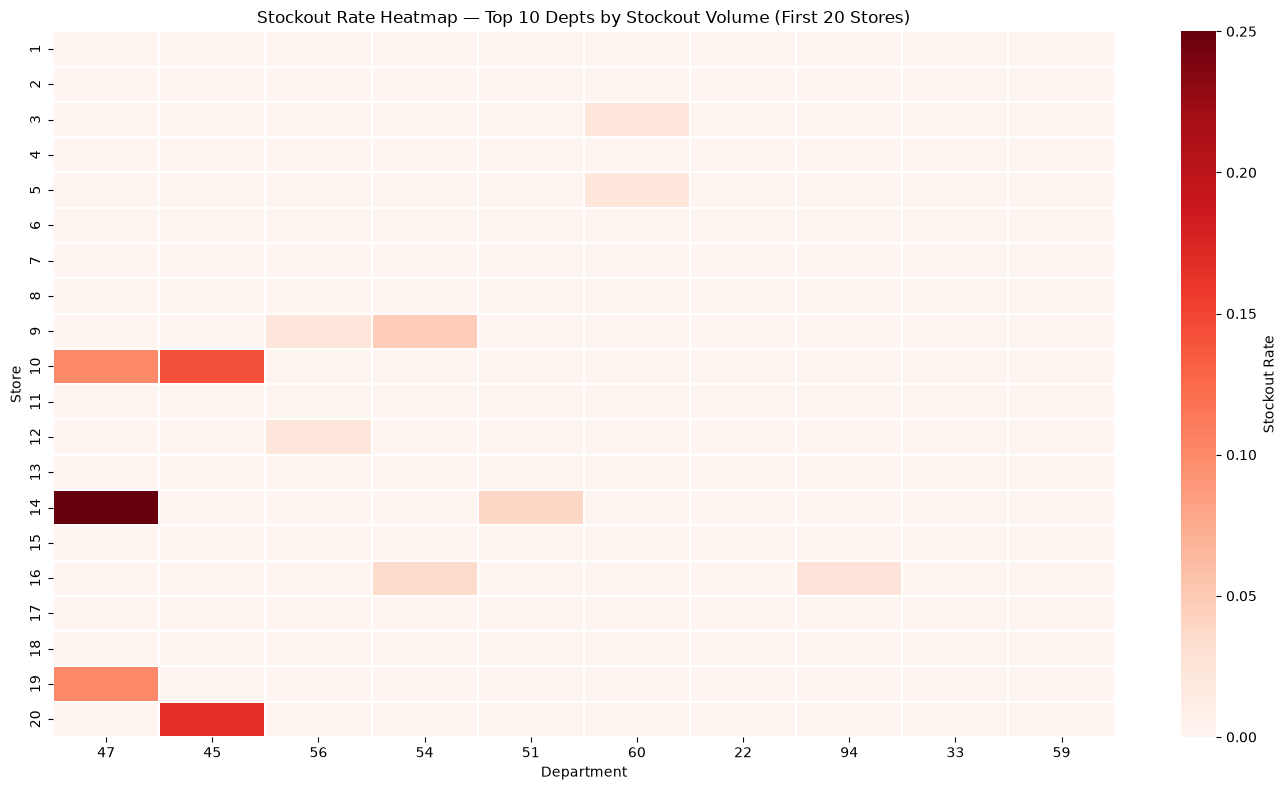

In [45]:
# --- Stockout heatmap by Store x Dept (top 10 depts) ---
stockout_pivot = (
    sim_df.groupby(['Store', 'Dept'])['Stockout']
    .mean()
    .unstack(fill_value=0)
)

top_depts = sim_df.groupby('Dept')['Stockout_Volume'].sum().nlargest(10).index
stockout_subset = stockout_pivot[top_depts].iloc[:20]

import seaborn as sns
plt.figure(figsize=(14, 8))
sns.heatmap(
    stockout_subset,
    cmap='Reds',
    annot=False,
    fmt='.2f',
    linewidths=0.3,
    cbar_kws={'label': 'Stockout Rate'}
)
plt.title('Stockout Rate Heatmap — Top 10 Depts by Stockout Volume (First 20 Stores)')
plt.xlabel('Department')
plt.ylabel('Store')
plt.tight_layout()
plt.show()

## Stockout Events

Stockouts occur when customer demand exceeds the available inventory.

Monitoring stockouts helps quantify lost sales and evaluate service performance.

In [46]:
stockouts = sample[
    sample["Stockout"] == 1
]

stockouts[
    [
        "Date",
        "Stockout_Volume",
    ]
]

,Date,Stockout_Volume
8143,2012-01-13,24.957882


In [47]:
simulation_df["Stockout"].value_counts()

Stockout
0    126853
1        68
Name: count, dtype: int64

In [48]:

(
    simulation_df
    .groupby(["Store", "Dept"])["Stockout"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

Store  Dept
17     93      1
16     94      1
10     45      1
16     54      1
5      60      1
3      60      1
10     47      1
19     47      1
45     45      1
16     96      1
Name: Stockout, dtype: int64

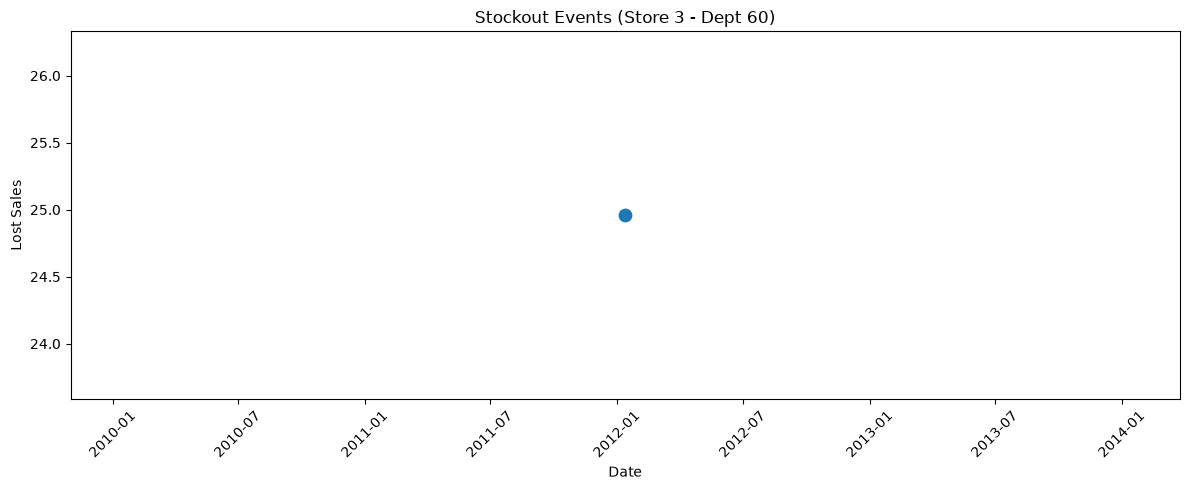

In [49]:
plt.figure(figsize=(12,5))

plt.scatter(
    stockouts["Date"],
    stockouts["Stockout_Volume"],
    s=80,
)

plt.title(
    f"Stockout Events (Store {store} - Dept {dept})"
)

plt.xlabel("Date")
plt.ylabel("Lost Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

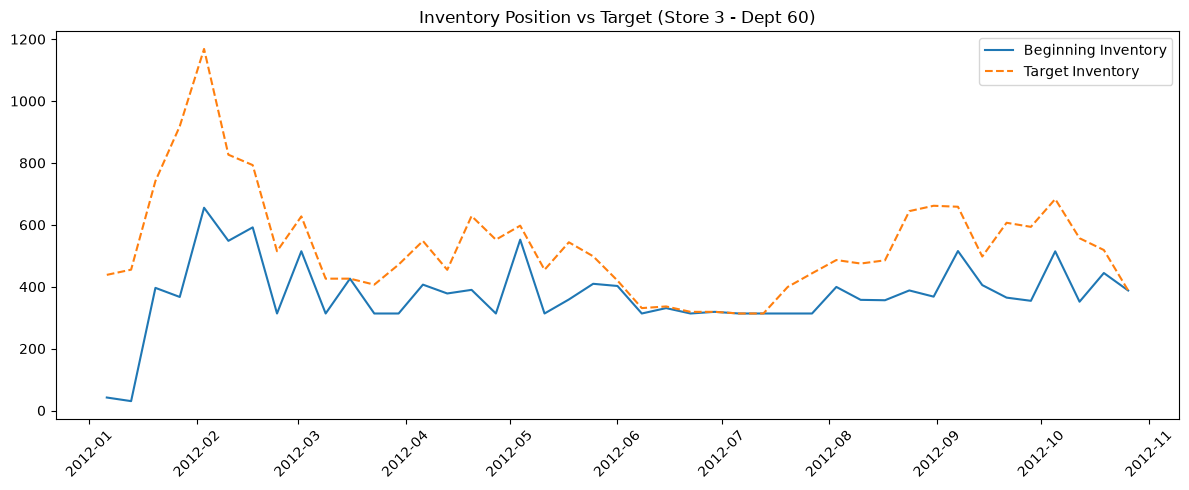

In [50]:
plt.figure(figsize=(12,5))

plt.plot(
    sample["Date"],
    sample["Beginning_Inventory"],
    label="Beginning Inventory",
)

plt.plot(
    sample["Date"],
    sample["Target_Inventory"],
    linestyle="--",
    label="Target Inventory",
)

plt.legend()

plt.title(
    f"Inventory Position vs Target (Store {store} - Dept {dept})"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Sample Reorder Recommendations

The table below shows the inventory decisions generated by the simulator for a representative Store–Department pair.

In [51]:
sample[
    [
        "Date",
        "Beginning_Inventory",
        "Target_Inventory",
        "Order_Quantity",
        "Ending_Inventory",
        "Stockout",
    ]
].head(15)

,Date,Beginning_Inventory,Target_Inventory,Order_Quantity,Ending_Inventory,Stockout
8142,2012-01-06,41.995430,438.337039,396.341609,30.330032,0
8143,2012-01-13,30.330032,455.153674,28.482033,0.000000,1
8144,2012-01-20,396.341609,741.618731,316.795090,338.450080,0
8145,2012-01-27,366.932113,918.499225,234.772022,338.450082,0
8146,2012-02-03,655.245172,1168.390582,278.373388,313.492211,0
8147,2012-02-10,548.264234,826.637591,0.000000,313.492200,0
8148,2012-02-17,591.865588,793.050433,201.184845,313.492236,0
8149,2012-02-24,313.492236,514.677081,0.000000,313.492236,0
8150,2012-03-02,514.677081,627.279590,112.602509,313.492206,0
8151,2012-03-09,313.492206,426.094706,0.000000,313.492206,0


# Business Conclusions

## Inventory Optimization Results

The demand forecasts generated by the XGBoost model were successfully transformed into inventory replenishment decisions using a Periodic Review Order-Up-To policy.

### Key Outcomes

- Safety stock was dynamically calculated from forecast uncertainty.
- Inventory targets adapted to future demand forecasts over the protection interval.
- Weekly replenishment orders maintained inventory availability while limiting unnecessary stock.
- Business KPIs such as Fill Rate, Stockout Rate, Holding Cost, and Ordering Cost provided quantitative measures of inventory performance.

## End-to-End Pipeline

Historical Sales

↓

Feature Engineering

↓

Demand Forecasting (XGBoost)

↓

Inventory Optimization

↓

Business KPIs

↓

Replenishment Recommendations

In [52]:
simulation_df.to_csv(
    "../results/inventory_simulation.csv",
    index=False,
)